# Motivation : pourquoi un arbre ?

## Y aura-t-il de la neige pour aller skier

Imaginons que nous voulions savoir s'il est possible de skier à un endroit donné et à une période donnée.

Deux variables : jour de l'année et latitude 

Une cible binaire : oui/non.

## Création du jeu de données exemple

In [7]:
from collections import namedtuple
import random
random.seed(42)

pôle_nord = 90
pôle_sud = -90

Point = namedtuple('Point', 'jour latitude')
points = [Point(random.randint(0,364),random.randint(pôle_sud, pôle_nord)) for _ in range(100)]


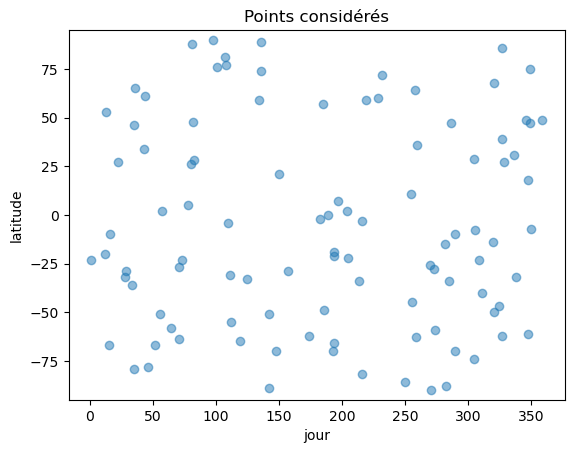

In [8]:
import matplotlib.pyplot as plt
import numpy as np

abscisses = [point.jour for point in points]
ordonnées = [point.latitude for point in points]

fig, ax = plt.subplots()

ax.set_title('Points considérés')
ax.scatter(abscisses, ordonnées, alpha=0.5)

ax.set_xlabel('jour')
ax.set_ylabel('latitude')

plt.ylim(-95, 95)
plt.show()

hiver boréal:
- latitude > 45
- mois novembre, décembre, janvier, février, mars, avril $\iff jour \in [[305, 365]] ou [[0, 120]]]$

hiver austral:
- latitude < -45
- mois juillet, août, septembre $\iff jour \in [[180, 270]]$


In [9]:
y = []
for point in points:
    if point.latitude<-45 and 180<=point.jour<=270:
        y.append(True)
    elif point.latitude>45 and (0<=point.jour<=120 or 305<=point.jour<=365):
        y.append(True)
    else:
        y.append(False)
# 1 = bleu
# 0 = rouge
couleurs = list(map(lambda y_i: 'blue' if y_i else 'red', y))

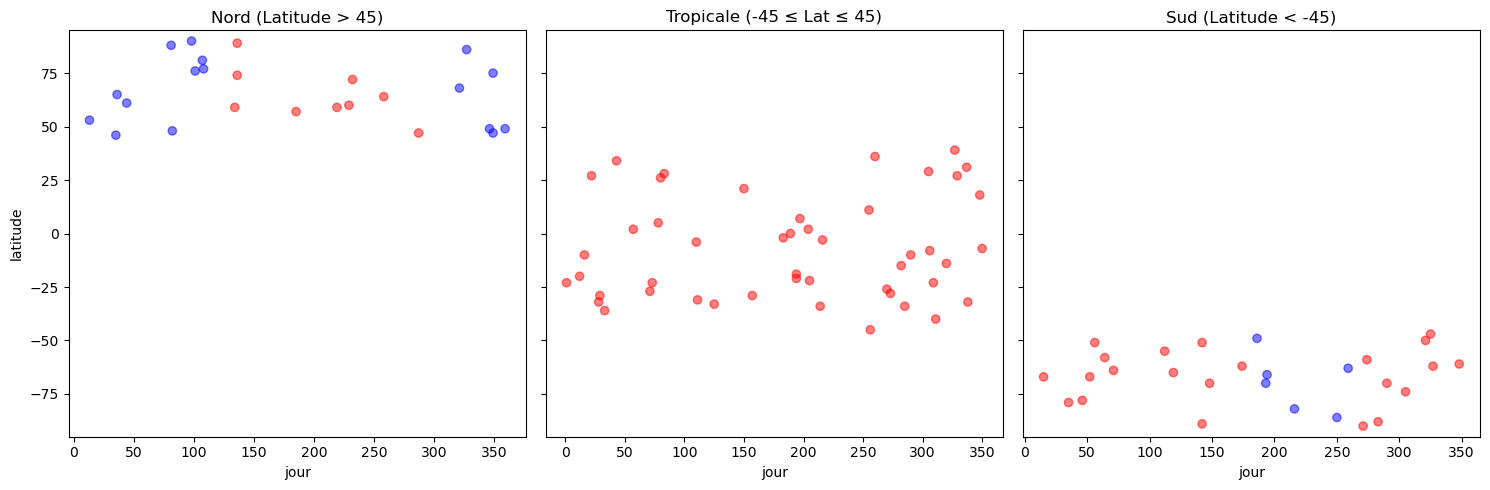

In [10]:
from collections import namedtuple
import random
import matplotlib.pyplot as plt

random.seed(42)

pôle_nord = 90
pôle_sud = -90

Point = namedtuple('Point', 'jour latitude')
points = [Point(random.randint(0, 364), random.randint(pôle_sud, pôle_nord)) for _ in range(100)]

# Détermination des couleurs selon vos conditions
couleurs = []
for point in points:
    if point.latitude < -45 and 180 <= point.jour <= 270:
        couleurs.append('blue')
    elif point.latitude > 45 and (0 <= point.jour <= 120 or 305 <= point.jour <= 365):
        couleurs.append('blue')
    else:
        couleurs.append('red')

# Création d'une figure avec 3 graphiques côte à côte (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# ---------------------------------------------------------
# 1. Graphique : Hémisphère Nord (Latitude > 45)
# ---------------------------------------------------------
x_nord = [p.jour for p in points if p.latitude > 45]
y_nord = [p.latitude for p in points if p.latitude > 45]
c_nord = [c for p, c in zip(points, couleurs) if p.latitude > 45]

axes[0].scatter(x_nord, y_nord, c=c_nord, alpha=0.5)
axes[0].set_title('Nord (Latitude > 45)')
axes[0].set_xlabel('jour')
axes[0].set_ylabel('latitude')
axes[0].set_ylim(-95, 95) # On force l'axe pour bien voir la position

# ---------------------------------------------------------
# 2. Graphique : Zone Tropicale (-45 <= Latitude <= 45)
# ---------------------------------------------------------
x_trop = [p.jour for p in points if -45 <= p.latitude <= 45]
y_trop = [p.latitude for p in points if -45 <= p.latitude <= 45]
c_trop = [c for p, c in zip(points, couleurs) if -45 <= p.latitude <= 45]

axes[1].scatter(x_trop, y_trop, c=c_trop, alpha=0.5)
axes[1].set_title('Tropicale (-45 ≤ Lat ≤ 45)')
axes[1].set_xlabel('jour')
axes[1].set_ylim(-95, 95)

# ---------------------------------------------------------
# 3. Graphique : Hémisphère Sud (Latitude < -45)
# ---------------------------------------------------------
x_sud = [p.jour for p in points if p.latitude < -45]
y_sud = [p.latitude for p in points if p.latitude < -45]
c_sud = [c for p, c in zip(points, couleurs) if p.latitude < -45]

axes[2].scatter(x_sud, y_sud, c=c_sud, alpha=0.5)
axes[2].set_title('Sud (Latitude < -45)')
axes[2].set_xlabel('jour')
axes[2].set_ylim(-95, 95)

# Ajustement automatique des marges pour un affichage propre
plt.tight_layout()
plt.show()

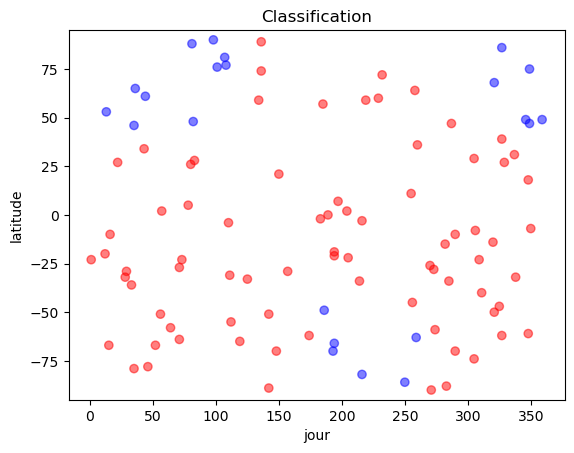

In [11]:
fig, ax = plt.subplots()

ax.set_title('Classification')
ax.scatter(abscisses, ordonnées, c=couleurs, alpha=0.5)

ax.set_xlabel('jour')
ax.set_ylabel('latitude')

plt.ylim(-95, 95)
plt.show()

## Quelle frontière utiliser pour séparer les deux classes ?

- Si j'ai un nouveau point, comment savoir de quelle couleur il devrait être?
- Une séparation linéaire unique est peu adaptée à ce problème.
- Idée : au lieu de chercher une grande frontière, on va découper progressivement l'espace.

## Représentation graphique des premières séparations

Critère de choix des séparations: avoir le plus de chance d'avoir des points bleus.

Séparateur: une ligne verticale ou horizontale. Comment la placer?

### Région condidérée: ensemble des points

Recherche d'une ligne de séparation pour avoir un classificateur binaire qui sépare le mieux possible entre deux régions, l'une sera considérée comme bleue et l'autre comme rouge.

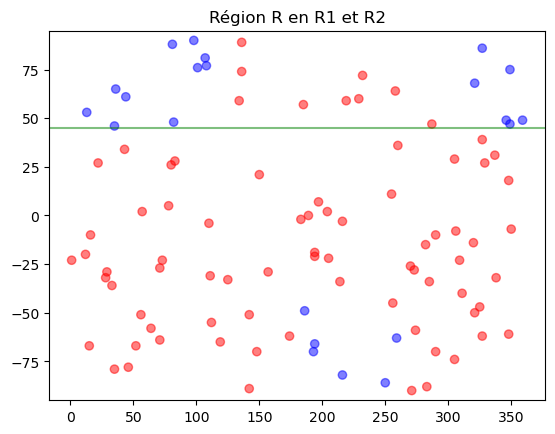

In [17]:
# Premier choix de séparation pour avoir le plus de chance d'avoir des points bleus
# latitude > 45
fig, ax = plt.subplots()

ax.set_title('Région R en R1 et R2')
ax.scatter(abscisses, ordonnées, c=couleurs, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)

plt.ylim(-95, 95)
plt.show()

In [18]:
import pandas as pd

df = pd.DataFrame({'x_1' : [point.jour for point in points],
                   'x_2' : [point.latitude for point in points],
                   'y': y,
                   'color': couleurs
                 })

In [14]:
df_R1= df[df.x_2 > 45].copy()


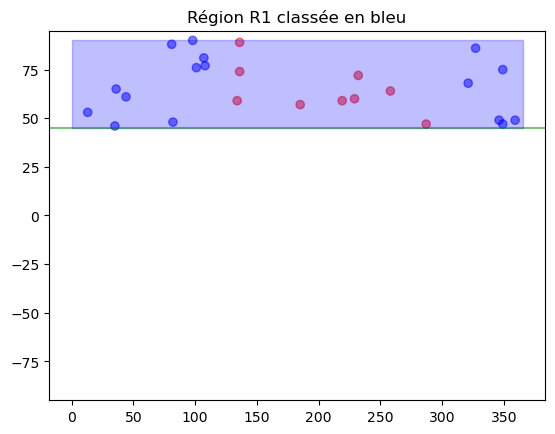

In [15]:
# Région R1 classée en bleu

fig, ax = plt.subplots()

ax.set_title('Région R1 classée en bleu')
ax.scatter(df_R1.x_1, df_R1.x_2, c=df_R1.color, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)
ax.fill_between(x=[-0,365], y1=45, y2=90, color='blue', alpha=.25)
plt.ylim(-95, 95)
plt.show()

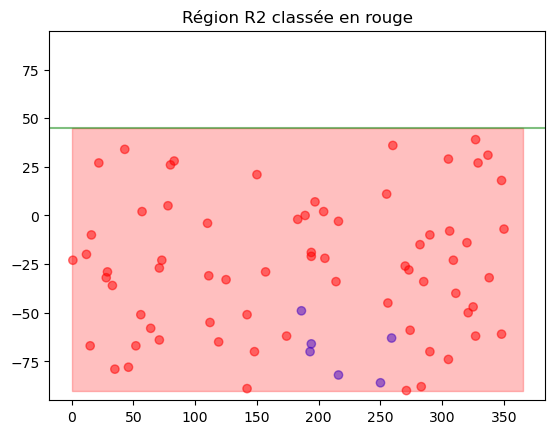

In [16]:
# Région R2 classée en rouge

df_R2= df[df.x_2 <= 45]
fig, ax = plt.subplots()

ax.set_title('Région R2 classée en rouge')
ax.scatter(df_R2.x_1, df_R2.x_2, c=df_R2.color, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)
ax.fill_between(x=[-0,365], y1=-90, y2=45, color='red', alpha=.25)

plt.ylim(-95, 95)
plt.show()

```mermaid
graph TD
    A{latitude > 45 ?}
    A -->|Oui| B[Bleu]
    A -->|Non| C[Rouge]
```

### Arbre de hauteur 1

Algorithme d'un arbre de décision d'une hauteur de 1

In [ ]:
# Arbre avec une hauteur = 1
def classification_h1(point):
    if point.latitude > 45:
        return True
    else:
        return False

### Arbre de hauteur 2


Algorithme d'un arbre de décision d'une hauteur de 2

On travaille de manière récursive sur chacune des régions R1 et R2 définies

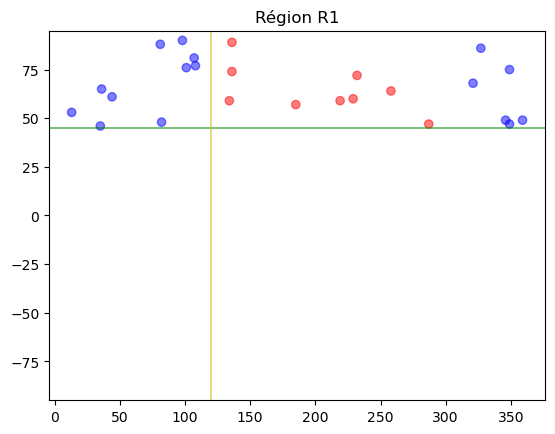

In [23]:
# Second choix de séparation pour avoir le plus de chance d'avoir des points bleus
# jour < 120

fig, ax = plt.subplots()

ax.set_title('Région R1')
ax.scatter(df_R1.x_1, df_R1.x_2, c=df_R1.color, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)
ax.axvline(x=120, color='y', alpha=0.5)
plt.ylim(-95, 95)
plt.show()

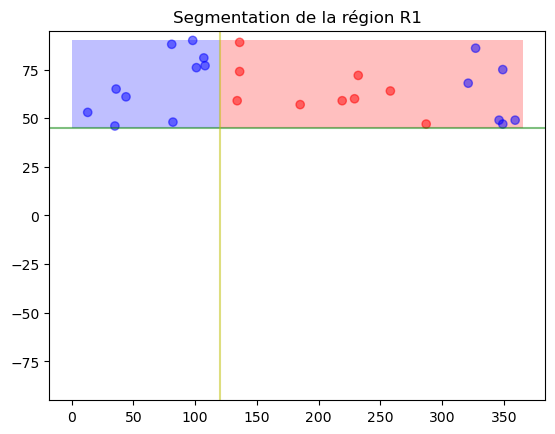

In [24]:
# Second choix de séparation pour avoir le plus de chance d'avoir des points bleus
# jour < 120

fig, ax = plt.subplots()

y1 = [45, 90]

ax.fill_betweenx(y1, 0, 120, facecolor='blue', alpha=0.25)
ax.fill_betweenx(y1, 120, 365, facecolor='red', alpha=0.25)

ax.set_title('Segmentation de la région R1')
ax.scatter(df_R1.x_1, df_R1.x_2, c=df_R1.color, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)
ax.axvline(x=120, color='y', alpha=0.5)
plt.ylim(-95, 95)
plt.show()

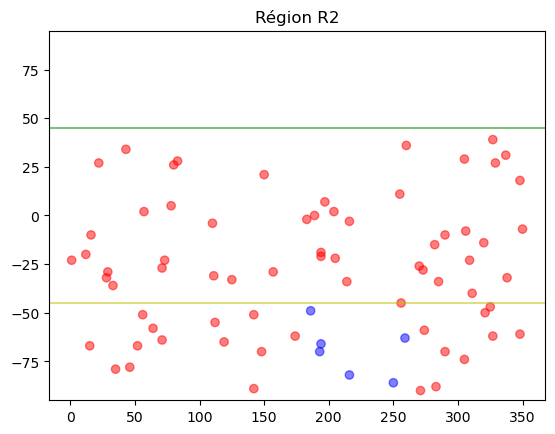

In [25]:
df_R2= df[df.x_2 <= 45]
fig, ax = plt.subplots()

ax.set_title('Région R2')
ax.scatter(df_R2.x_1, df_R2.x_2, c=df_R2.color, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)
ax.axhline(y=-45, color='y', alpha=0.5)
plt.ylim(-95, 95)
plt.show()

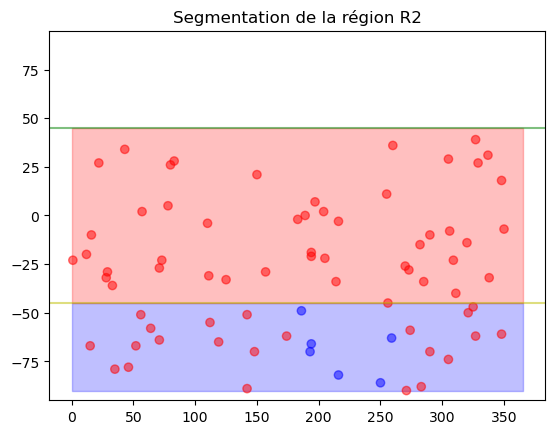

In [26]:
df_R2= df[df.x_2 <= 45]
fig, ax = plt.subplots()

ax.fill_between(x=[0,365], y1=-90, y2=-45, color='blue', alpha=.25)
ax.fill_between(x=[0,365], y1=-45, y2=45, color='red', alpha=.25)


ax.set_title('Segmentation de la région R2')
ax.scatter(df_R2.x_1, df_R2.x_2, c=df_R2.color, alpha=0.5)
ax.axhline(y=45, color='g', alpha=0.5)
ax.axhline(y=-45, color='y', alpha=0.5)

plt.ylim(-95, 95)
plt.show()


```mermaid
graph TD
    %% Nœuds de décision (losanges, fond orange)
    A{"latitude > 45 ?"}
    B{"jour < 120 ?"}
    C{"latitude < -45 ?"}
    
    %% Feuilles (Résultats, ellipses, fond vert pour True, rouge pour False)
    D(["True"])
    E(["False"])
    F(["True"])
    G(["False"])
    
    %% Connexions avec étiquettes
    A -->|"Bleu"| B
    A -->|"Rouge"| C
    
    B -->|"Bleu"| D
    B -->|"Rouge"| E
    
    C -->|"Bleu"| F
    C -->|"Rouge"| G

    %% Définition des styles personnalisés
    classDef decision fill:#ffcc80,stroke:#e65100,stroke-width:2px,color:#000
    classDef resultOui fill:#a5d6a7,stroke:#2e7d32,stroke-width:2px,color:#000
    classDef resultNon fill:#ef9a9a,stroke:#c62828,stroke-width:2px,color:#000

    %% Application des styles
    class A,B,C decision
    class D,F resultOui
    class E,G resultNon
```